# Notebook 05 — Visualization & Interactive Maps
**Project:** Natural Gas Pipeline Risk Mapping & Incident Prediction  
**Author:** Ankita Prashant Naik  

This notebook produces the final interactive Folium risk map and all publication-quality static charts for the GitHub Pages portfolio.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import folium
from folium.plugins import HeatMap
from IPython.display import IFrame, display
from pathlib import Path

from src.visualization.pipeline_map import load_data, build_map

plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})
PROCESSED = Path('../data/processed')
OUTPUTS = Path('../outputs')
OUTPUTS.mkdir(exist_ok=True)

## 1. Build & Display Interactive Folium Map

In [2]:
df, risk_df = load_data()
print(f'Incidents: {len(df):,}  |  Risk scores available: {risk_df is not None}')

m = build_map(df, risk_df)

map_path = OUTPUTS / 'pipeline_risk_map.html'
m.save(str(map_path))
print(f'Map saved → {map_path}')

Incidents: 2,675  |  Risk scores available: True


Map saved → ../outputs/pipeline_risk_map.html


In [3]:
# Render inline in Jupyter
display(IFrame(src=str(map_path), width='100%', height=550))

## 2. Risk Score Distribution

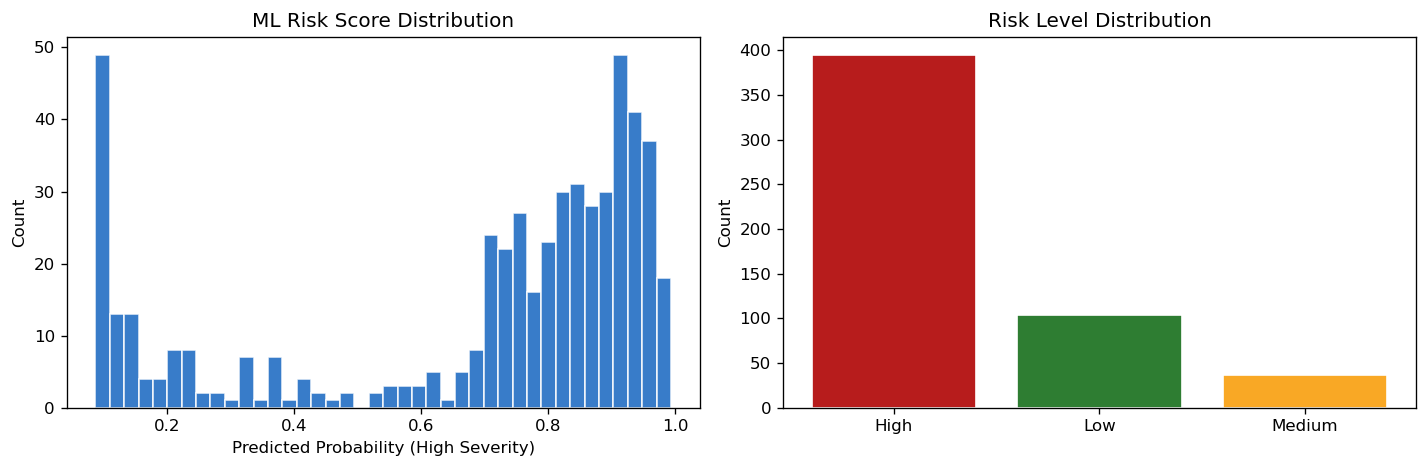

In [4]:
if risk_df is not None and 'risk_score' in risk_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(risk_df['risk_score'], bins=40, color='#1565C0', edgecolor='white', alpha=0.85)
    axes[0].set_title('ML Risk Score Distribution')
    axes[0].set_xlabel('Predicted Probability (High Severity)')
    axes[0].set_ylabel('Count')

    if 'risk_label' in risk_df.columns:
        label_counts = risk_df['risk_label'].value_counts()
        colors = {'Low': '#2E7D32', 'Medium': '#F9A825', 'High': '#B71C1C'}
        bar_colors = [colors.get(l, '#607D8B') for l in label_counts.index]
        axes[1].bar(label_counts.index, label_counts.values, color=bar_colors, edgecolor='white')
        axes[1].set_title('Risk Level Distribution')
        axes[1].set_ylabel('Count')

    plt.tight_layout()
    plt.savefig(OUTPUTS / 'risk_distribution.png', bbox_inches='tight')
    plt.show()
else:
    print('Run notebook 04 first to generate risk_scores.csv')

## 3. Incident Timeline Heatmap (Year × Month)

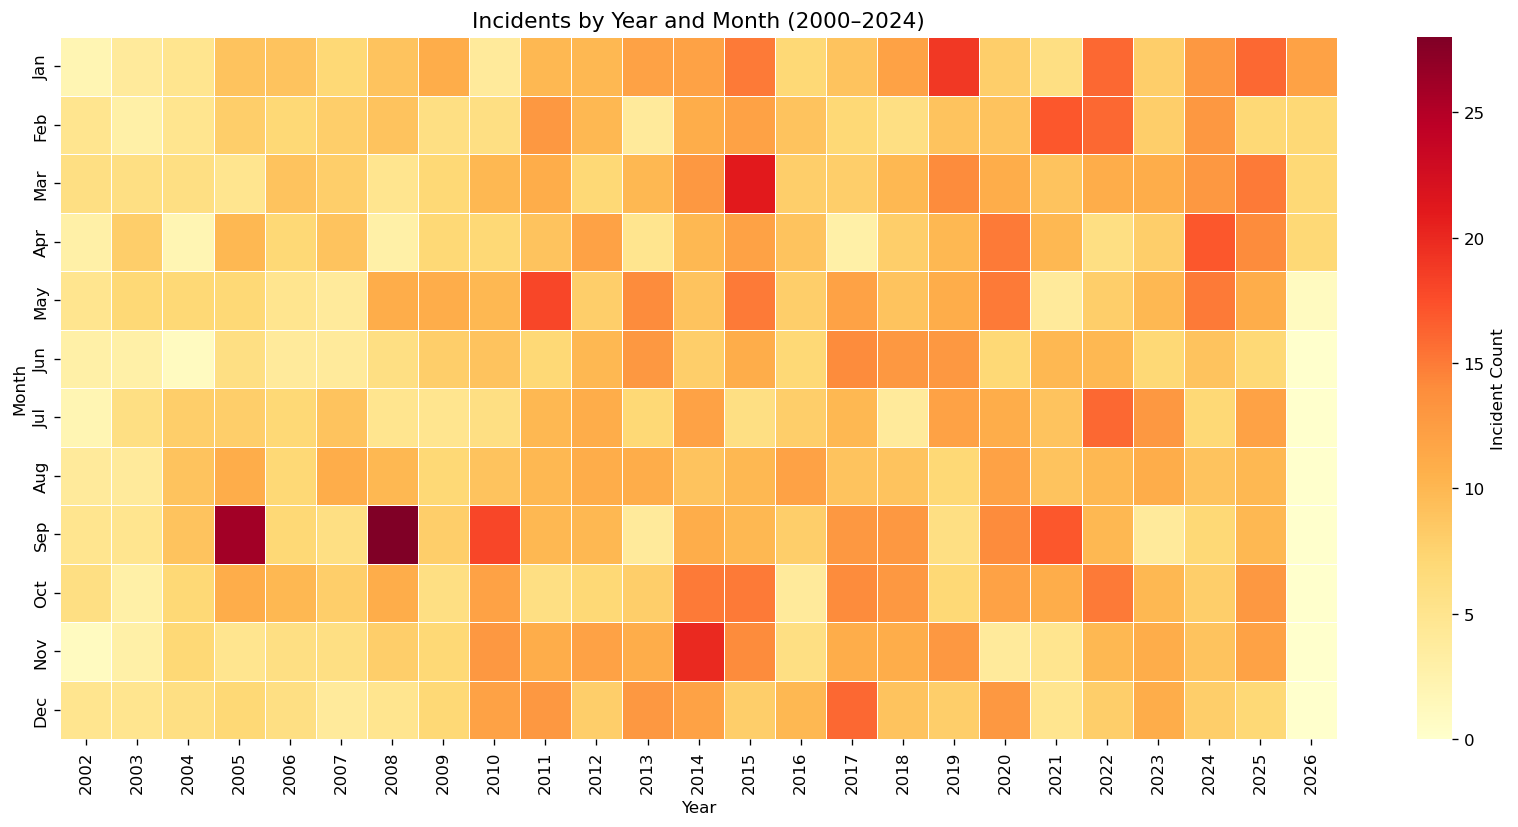

In [5]:
if 'IMONTH' in df.columns and 'IYEAR' in df.columns:
    recent = df[df['IYEAR'] >= 2000].copy()
    recent['IMONTH'] = pd.to_numeric(recent['IMONTH'], errors='coerce')
    pivot = recent.groupby(['IYEAR', 'IMONTH']).size().unstack(fill_value=0)

    month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec']

    fig, ax = plt.subplots(figsize=(14, 7))
    sns.heatmap(
        pivot.T, cmap='YlOrRd', linewidths=0.3,
        yticklabels=month_labels[:pivot.shape[1]], ax=ax,
        cbar_kws={'label': 'Incident Count'}
    )
    ax.set_title('Incidents by Year and Month (2000–2024)', fontsize=13)
    ax.set_xlabel('Year')
    ax.set_ylabel('Month')
    plt.tight_layout()
    plt.savefig(OUTPUTS / 'incident_timeline_heatmap.png', bbox_inches='tight')
    plt.show()

## 4. Severity vs Cause vs Damage — Multi-Panel Summary

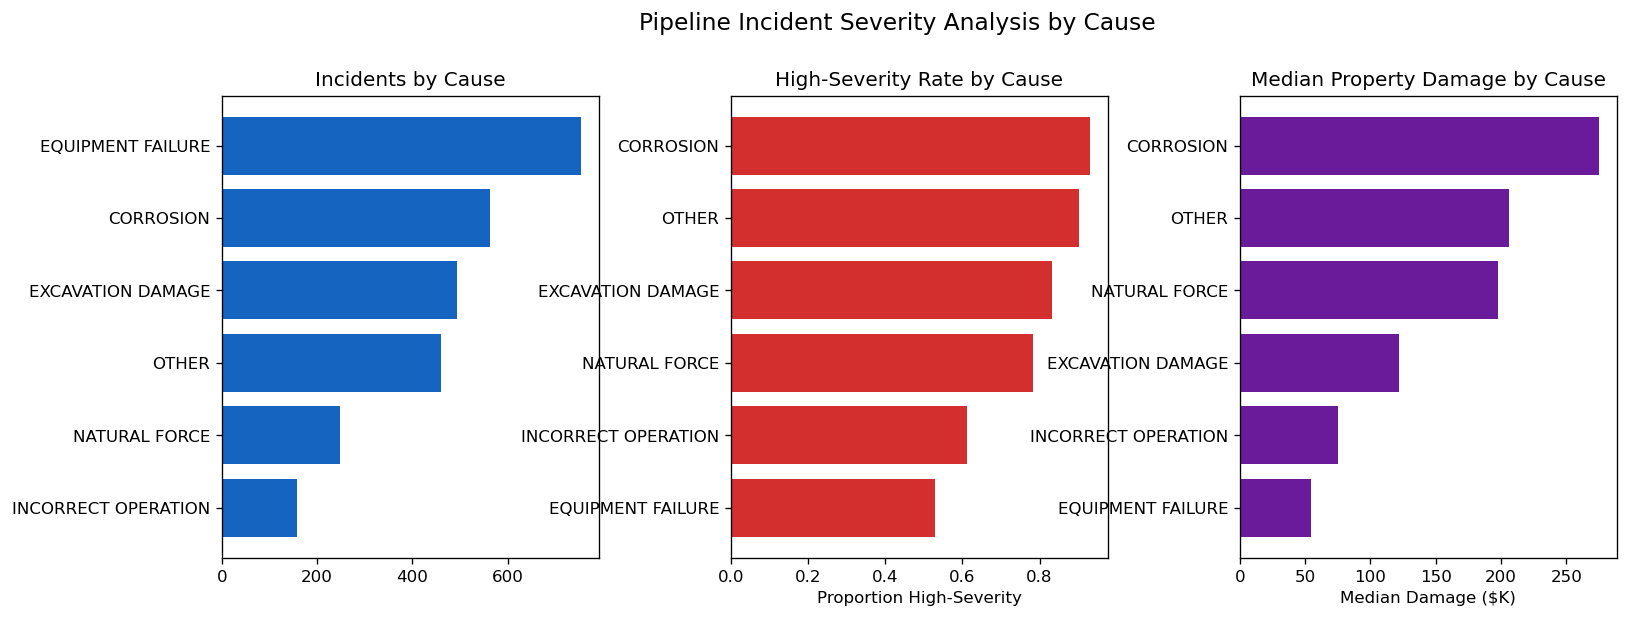

In [6]:
cause_col = 'CAUSE_CLEAN' if 'CAUSE_CLEAN' in df.columns else 'CAUSE'

if cause_col in df.columns:
    fig = plt.figure(figsize=(15, 5))
    gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

    # Panel 1: incident count by cause
    ax1 = fig.add_subplot(gs[0])
    cause_counts = df[cause_col].value_counts()
    ax1.barh(cause_counts.index, cause_counts.values, color='#1565C0')
    ax1.set_title('Incidents by Cause')
    ax1.invert_yaxis()

    # Panel 2: high-severity rate by cause
    ax2 = fig.add_subplot(gs[1])
    sev_rate = df.groupby(cause_col)['high_severity'].mean().sort_values()
    ax2.barh(sev_rate.index, sev_rate.values, color='#D32F2F')
    ax2.set_title('High-Severity Rate by Cause')
    ax2.set_xlabel('Proportion High-Severity')

    # Panel 3: median damage by cause
    ax3 = fig.add_subplot(gs[2])
    med_damage = df.groupby(cause_col)['PRPTY_DAMAGE_COSTS'].median().sort_values()
    ax3.barh(med_damage.index, med_damage.values / 1000, color='#6A1B9A')
    ax3.set_title('Median Property Damage by Cause')
    ax3.set_xlabel('Median Damage ($K)')

    plt.suptitle('Pipeline Incident Severity Analysis by Cause', fontsize=14, y=1.02)
    plt.savefig(OUTPUTS / 'cause_severity_summary.png', bbox_inches='tight')
    plt.show()

## 5. Kepler.gl Dashboard (Optional)

In [7]:
# To build the Kepler.gl dashboard:
# python -m src.visualization.risk_dashboard
#
# Or run in Jupyter:
try:
    from keplergl import KeplerGl
    df_kepler = df[['LOCATION_LATITUDE', 'LOCATION_LONGITUDE',
                    'high_severity', 'PRPTY_DAMAGE_COSTS', 'FATALITIES']].rename(
        columns={'LOCATION_LATITUDE': 'latitude', 'LOCATION_LONGITUDE': 'longitude'}
    ).dropna(subset=['latitude', 'longitude'])

    map_kepler = KeplerGl(height=500)
    map_kepler.add_data(data=df_kepler, name='incidents')
    display(map_kepler)
except ImportError:
    print('keplergl not installed. Run: pip install keplergl')

keplergl not installed. Run: pip install keplergl


## 6. Final Output Checklist

In [8]:
expected_outputs = [
    'pipeline_risk_map.html',
    'roc_curve.png',
    'confusion_matrix.png',
    'shap_summary.png',
    'shap_waterfall.png',
    'feature_importance.png',
    'risk_distribution.png',
    'county_choropleth.png',
]

print('Output files:')
for fname in expected_outputs:
    path = OUTPUTS / fname
    status = '✓' if path.exists() else '✗ MISSING'
    print(f'  {status}  {fname}')

Output files:
  ✓  pipeline_risk_map.html
  ✓  roc_curve.png
  ✓  confusion_matrix.png
  ✓  shap_summary.png
  ✓  shap_waterfall.png
  ✓  feature_importance.png
  ✓  risk_distribution.png
  ✓  county_choropleth.png
